# PART 5: Regression Analysis

## Correlation & Regression

### Getting and Preparing the Data (Part 1) 

In [1]:
import pandas as pd

In [26]:
movie = pd.read_csv("movies_metadata.csv", low_memory= False)
movie.head()

,adult,belongs_to_collection,budget,genres,homepage,id,imdb_id,original_language,original_title,overview,...,release_date,revenue,runtime,spoken_languages,status,tagline,title,video,vote_average,vote_count
0,False,"{'id': 10194, 'name': 'Toy Story Collection', ...",30000000,"[{'id': 16, 'name': 'Animation'}, {'id': 35, '...",http://toystory.disney.com/toy-story,862,tt0114709,en,Toy Story,"Led by Woody, Andy's toys live happily in his ...",...,1995-10-30,373554033.0,81.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,NaN,Toy Story,False,7.7,5415.0
1,False,NaN,65000000,"[{'id': 12, 'name': 'Adventure'}, {'id': 14, '...",NaN,8844,tt0113497,en,Jumanji,When siblings Judy and Peter discover an encha...,...,1995-12-15,262797249.0,104.0,"[{'iso_639_1': 'en', 'name': 'English'}, {'iso...",Released,Roll the dice and unleash the excitement!,Jumanji,False,6.9,2413.0
2,False,"{'id': 119050, 'name': 'Grumpy Old Men Collect...",0,"[{'id': 10749, 'name': 'Romance'}, {'id': 35, ...",NaN,15602,tt0113228,en,Grumpier Old Men,A family wedding reignites the ancient feud be...,...,1995-12-22,0.0,101.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,Still Yelling. Still Fighting. Still Ready for...,Grumpier Old Men,False,6.5,92.0
3,False,NaN,16000000,"[{'id': 35, 'name': 'Comedy'}, {'id': 18, 'nam...",NaN,31357,tt0114885,en,Waiting to Exhale,"Cheated on, mistreated and stepped on, the wom...",...,1995-12-22,81452156.0,127.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,Friends are the people who let you be yourself...,Waiting to Exhale,False,6.1,34.0
4,False,"{'id': 96871, 'name': 'Father of the Bride Col...",0,"[{'id': 35, 'name': 'Comedy'}]",NaN,11862,tt0113041,en,Father of the Bride Part II,Just when George Banks has recovered from his ...,...,1995-02-10,76578911.0,106.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,Just When His World Is Back To Normal... He's ...,Father of the Bride Part II,False,5.7,173.0


In [27]:
movie.columns = movie.columns.str.capitalize()
movie.columns

Index(['Adult', 'Belongs_to_collection', 'Budget', 'Genres', 'Homepage', 'Id',
       'Imdb_id', 'Original_language', 'Original_title', 'Overview',
       'Popularity', 'Poster_path', 'Production_companies',
       'Production_countries', 'Release_date', 'Revenue', 'Runtime',
       'Spoken_languages', 'Status', 'Tagline', 'Title', 'Video',
       'Vote_average', 'Vote_count'],
      dtype='object')

In [28]:
movie.info(memory_usage = "deep")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45466 entries, 0 to 45465
Data columns (total 24 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Adult                  45466 non-null  object 
 1   Belongs_to_collection  4494 non-null   object 
 2   Budget                 45466 non-null  object 
 3   Genres                 45466 non-null  object 
 4   Homepage               7782 non-null   object 
 5   Id                     45466 non-null  object 
 6   Imdb_id                45449 non-null  object 
 7   Original_language      45455 non-null  object 
 8   Original_title         45466 non-null  object 
 9   Overview               44512 non-null  object 
 10  Popularity             45461 non-null  object 
 11  Poster_path            45080 non-null  object 
 12  Production_companies   45463 non-null  object 
 13  Production_countries   45463 non-null  object 
 14  Release_date           45379 non-null  object 
 15  Re

In [29]:
pd.to_datetime(movie.Release_date, errors = "coerce")

0       1995-10-30
1       1995-12-15
2       1995-12-22
3       1995-12-22
4       1995-02-10
           ...    
45461          NaT
45462   2011-11-17
45463   2003-08-01
45464   1917-10-21
45465   2017-06-09
Name: Release_date, Length: 45466, dtype: datetime64[ns]

In [30]:
movie = movie.set_index(pd.to_datetime(movie.Release_date, errors = "coerce")).drop(columns = ["Release_date"])
movie

,Adult,Belongs_to_collection,Budget,Genres,Homepage,Id,Imdb_id,Original_language,Original_title,Overview,...,Production_countries,Revenue,Runtime,Spoken_languages,Status,Tagline,Title,Video,Vote_average,Vote_count
Release_date,,,,,,,,,,,,,,,,,,,,,
1995-10-30,False,"{'id': 10194, 'name': 'Toy Story Collection', ...",30000000,"[{'id': 16, 'name': 'Animation'}, {'id': 35, '...",http://toystory.disney.com/toy-story,862,tt0114709,en,Toy Story,"Led by Woody, Andy's toys live happily in his ...",...,"[{'iso_3166_1': 'US', 'name': 'United States o...",373554033.0,81.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,NaN,Toy Story,False,7.7,5415.0
1995-12-15,False,NaN,65000000,"[{'id': 12, 'name': 'Adventure'}, {'id': 14, '...",NaN,8844,tt0113497,en,Jumanji,When siblings Judy and Peter discover an encha...,...,"[{'iso_3166_1': 'US', 'name': 'United States o...",262797249.0,104.0,"[{'iso_639_1': 'en', 'name': 'English'}, {'iso...",Released,Roll the dice and unleash the excitement!,Jumanji,False,6.9,2413.0
1995-12-22,False,"{'id': 119050, 'name': 'Grumpy Old Men Collect...",0,"[{'id': 10749, 'name': 'Romance'}, {'id': 35, ...",NaN,15602,tt0113228,en,Grumpier Old Men,A family wedding reignites the ancient feud be...,...,"[{'iso_3166_1': 'US', 'name': 'United States o...",0.0,101.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,Still Yelling. Still Fighting. Still Ready for...,Grumpier Old Men,False,6.5,92.0
1995-12-22,False,NaN,16000000,"[{'id': 35, 'name': 'Comedy'}, {'id': 18, 'nam...",NaN,31357,tt0114885,en,Waiting to Exhale,"Cheated on, mistreated and stepped on, the wom...",...,"[{'iso_3166_1': 'US', 'name': 'United States o...",81452156.0,127.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,Friends are the people who let you be yourself...,Waiting to Exhale,False,6.1,34.0
1995-02-10,False,"{'id': 96871, 'name': 'Father of the Bride Col...",0,"[{'id': 35, 'name': 'Comedy'}]",NaN,11862,tt0113041,en,Father of the Bride Part II,Just when George Banks has recovered from his ...,...,"[{'iso_3166_1': 'US', 'name': 'United States o...",76578911.0,106.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,Just When His World Is Back To Normal... He's ...,Father of the Bride Part II,False,5.7,173.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
NaT,False,NaN,0,"[{'id': 18, 'name': 'Drama'}, {'id': 10751, 'n...",http://www.imdb.com/title/tt6209470/,439050,tt6209470,fa,رگ خواب,Rising and falling between a man and woman.,...,"[{'iso_3166_1': 'IR', 'name': 'Iran'}]",0.0,90.0,"[{'iso_639_1': 'fa', 'name': 'فارسی'}]",Released,Rising and falling between a man and woman,Subdue,False,4.0,1.0
2011-11-17,False,NaN,0,"[{'id': 18, 'name': 'Drama'}]",NaN,111109,tt2028550,tl,Siglo ng Pagluluwal,An artist struggles to finish his work while a...,...,"[{'iso_3166_1': 'PH', 'name': 'Philippines'}]",0.0,360.0,"[{'iso_639_1': 'tl', 'name': ''}]",Released,NaN,Century of Birthing,False,9.0,3.0
2003-08-01,False,NaN,0,"[{'id': 28, 'name': 'Action'}, {'id': 18, 'nam...",NaN,67758,tt0303758,en,Betrayal,"When one of her hits goes wrong, a professiona...",...,"[{'iso_3166_1': 'US', 'name': 'United States o...",0.0,90.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,A deadly game of wits.,Betrayal,False,3.8,6.0


In [31]:
movie["Original_language"] = movie["Original_language"].str.upper()

In [32]:
movie["Original_language"].value_counts()

Original_language
EN       32269
FR        2438
IT        1529
JA        1350
DE        1080
         ...  
ZU           1
QU           1
104.0        1
LA           1
SI           1
Name: count, Length: 92, dtype: int64

so we need to drop its column:

In [33]:
movie.sort_index(inplace = True)

In [34]:
movie

,Adult,Belongs_to_collection,Budget,Genres,Homepage,Id,Imdb_id,Original_language,Original_title,Overview,...,Production_countries,Revenue,Runtime,Spoken_languages,Status,Tagline,Title,Video,Vote_average,Vote_count
Release_date,,,,,,,,,,,,,,,,,,,,,
1874-12-09,False,NaN,0,"[{'id': 99, 'name': 'Documentary'}]",NaN,315946,tt3155794,XX,Passage de Venus,Photo sequence of the rare transit of Venus ov...,...,"[{'iso_3166_1': 'FR', 'name': 'France'}]",0.0,1.0,"[{'iso_639_1': 'xx', 'name': 'No Language'}]",Released,NaN,Passage of Venus,False,6.0,19.0
1878-06-14,False,NaN,0,"[{'id': 99, 'name': 'Documentary'}]",NaN,194079,tt2221420,EN,Sallie Gardner at a Gallop,Sallie Gardner at a Gallop was one of the earl...,...,"[{'iso_3166_1': 'US', 'name': 'United States o...",0.0,1.0,"[{'iso_639_1': 'xx', 'name': 'No Language'}]",Released,NaN,Sallie Gardner at a Gallop,False,6.2,25.0
1883-11-19,False,NaN,0,"[{'id': 99, 'name': 'Documentary'}]",NaN,426903,tt5459794,EN,Buffalo Running,Individual photographs of the running of a buf...,...,"[{'iso_3166_1': 'US', 'name': 'United States o...",0.0,1.0,"[{'iso_639_1': 'xx', 'name': 'No Language'}]",Released,NaN,Buffalo Running,False,5.4,7.0
1887-08-18,False,NaN,0,"[{'id': 99, 'name': 'Documentary'}]",NaN,159897,tt2075247,XX,Man Walking Around a Corner,The last remaining production of Le Prince's L...,...,"[{'iso_3166_1': 'US', 'name': 'United States o...",0.0,1.0,"[{'iso_639_1': 'xx', 'name': 'No Language'}]",Released,NaN,Man Walking Around a Corner,False,4.1,17.0
1888-01-01,False,NaN,0,"[{'id': 99, 'name': 'Documentary'}]",NaN,96882,tt1758563,XX,Accordion Player,The last remaining film of Le Prince's LPCCP T...,...,"[{'iso_3166_1': 'GB', 'name': 'United Kingdom'}]",0.0,1.0,"[{'iso_639_1': 'xx', 'name': 'No Language'}]",Released,NaN,Accordion Player,False,4.4,18.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
NaT,False,NaN,0,[],NaN,438910,tt0810384,RU,Konstruktor krasnogo tsveta -1993,Engineering Red - 1993 Dir: Andrey I. Y. Petr...,...,[],0.0,76.0,[],Released,NaN,Engineering Red,False,6.0,2.0
NaT,False,NaN,0,"[{'id': 9648, 'name': 'Mystery'}, {'id': 878, ...",NaN,433711,tt3158690,EN,All Superheroes Must Die 2: The Last Superhero,"In a no holds barred documentary, acclaimed jo...",...,[],0.0,74.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,NaN,All Superheroes Must Die 2: The Last Superhero,False,4.0,1.0
NaT,False,NaN,0,[],NaN,335251,tt1883368,EN,The Land Where the Blues Began,An exploration of the musical and social origi...,...,[],0.0,0.0,[],Released,NaN,The Land Where the Blues Began,False,0.0,0.0


In [36]:
movie["Homepage"].value_counts(ascending = False)

Homepage
http://www.georgecarlin.com                     12
http://www.wernerherzog.com/films-by.html        7
http://breakblade.jp/                            6
http://www.kungfupanda.com/                      4
http://phantasm.com                              4
                                                ..
http://www.ghostsofgirlfriendspastmovie.com/     1
http://www.yearofthecarnivore.com/               1
http://www.sonofbabylon.com/                     1
http://www.losviajesdelviento.net/               1
http://www.imdb.com/title/tt6209470/             1
Name: count, Length: 7673, dtype: int64

In [37]:
movie[movie.isna().any(axis = 1)]

,Adult,Belongs_to_collection,Budget,Genres,Homepage,Id,Imdb_id,Original_language,Original_title,Overview,...,Production_countries,Revenue,Runtime,Spoken_languages,Status,Tagline,Title,Video,Vote_average,Vote_count
Release_date,,,,,,,,,,,,,,,,,,,,,
1874-12-09,False,NaN,0,"[{'id': 99, 'name': 'Documentary'}]",NaN,315946,tt3155794,XX,Passage de Venus,Photo sequence of the rare transit of Venus ov...,...,"[{'iso_3166_1': 'FR', 'name': 'France'}]",0.0,1.0,"[{'iso_639_1': 'xx', 'name': 'No Language'}]",Released,NaN,Passage of Venus,False,6.0,19.0
1878-06-14,False,NaN,0,"[{'id': 99, 'name': 'Documentary'}]",NaN,194079,tt2221420,EN,Sallie Gardner at a Gallop,Sallie Gardner at a Gallop was one of the earl...,...,"[{'iso_3166_1': 'US', 'name': 'United States o...",0.0,1.0,"[{'iso_639_1': 'xx', 'name': 'No Language'}]",Released,NaN,Sallie Gardner at a Gallop,False,6.2,25.0
1883-11-19,False,NaN,0,"[{'id': 99, 'name': 'Documentary'}]",NaN,426903,tt5459794,EN,Buffalo Running,Individual photographs of the running of a buf...,...,"[{'iso_3166_1': 'US', 'name': 'United States o...",0.0,1.0,"[{'iso_639_1': 'xx', 'name': 'No Language'}]",Released,NaN,Buffalo Running,False,5.4,7.0
1887-08-18,False,NaN,0,"[{'id': 99, 'name': 'Documentary'}]",NaN,159897,tt2075247,XX,Man Walking Around a Corner,The last remaining production of Le Prince's L...,...,"[{'iso_3166_1': 'US', 'name': 'United States o...",0.0,1.0,"[{'iso_639_1': 'xx', 'name': 'No Language'}]",Released,NaN,Man Walking Around a Corner,False,4.1,17.0
1888-01-01,False,NaN,0,"[{'id': 99, 'name': 'Documentary'}]",NaN,96882,tt1758563,XX,Accordion Player,The last remaining film of Le Prince's LPCCP T...,...,"[{'iso_3166_1': 'GB', 'name': 'United Kingdom'}]",0.0,1.0,"[{'iso_639_1': 'xx', 'name': 'No Language'}]",Released,NaN,Accordion Player,False,4.4,18.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
NaT,False,NaN,0,[],NaN,438910,tt0810384,RU,Konstruktor krasnogo tsveta -1993,Engineering Red - 1993 Dir: Andrey I. Y. Petr...,...,[],0.0,76.0,[],Released,NaN,Engineering Red,False,6.0,2.0
NaT,False,NaN,0,"[{'id': 9648, 'name': 'Mystery'}, {'id': 878, ...",NaN,433711,tt3158690,EN,All Superheroes Must Die 2: The Last Superhero,"In a no holds barred documentary, acclaimed jo...",...,[],0.0,74.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,NaN,All Superheroes Must Die 2: The Last Superhero,False,4.0,1.0
NaT,False,NaN,0,[],NaN,335251,tt1883368,EN,The Land Where the Blues Began,An exploration of the musical and social origi...,...,[],0.0,0.0,[],Released,NaN,The Land Where the Blues Began,False,0.0,0.0


In [38]:
df = movie.loc[:, ["Title", "Budget", "Revenue"]].copy()
df

,Title,Budget,Revenue
Release_date,,,
1874-12-09,Passage of Venus,0,0.0
1878-06-14,Sallie Gardner at a Gallop,0,0.0
1883-11-19,Buffalo Running,0,0.0
1887-08-18,Man Walking Around a Corner,0,0.0
1888-01-01,Accordion Player,0,0.0
...,...,...,...
NaT,Engineering Red,0,0.0
NaT,All Superheroes Must Die 2: The Last Superhero,0,0.0
NaT,The Land Where the Blues Began,0,0.0


In [39]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 45466 entries, 1874-12-09 to NaT
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Title    45460 non-null  object 
 1   Budget   45466 non-null  object 
 2   Revenue  45460 non-null  float64
dtypes: float64(1), object(2)
memory usage: 1.4+ MB


In [40]:
df["Budget"] = pd.to_numeric(df["Budget"], errors = "coerce")

In [41]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 45466 entries, 1874-12-09 to NaT
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Title    45460 non-null  object 
 1   Budget   45463 non-null  float64
 2   Revenue  45460 non-null  float64
dtypes: float64(2), object(1)
memory usage: 1.4+ MB


### Getting and preparing the Data (Part 2) 

In [42]:
df

,Title,Budget,Revenue
Release_date,,,
1874-12-09,Passage of Venus,0.0,0.0
1878-06-14,Sallie Gardner at a Gallop,0.0,0.0
1883-11-19,Buffalo Running,0.0,0.0
1887-08-18,Man Walking Around a Corner,0.0,0.0
1888-01-01,Accordion Player,0.0,0.0
...,...,...,...
NaT,Engineering Red,0.0,0.0
NaT,All Superheroes Must Die 2: The Last Superhero,0.0,0.0
NaT,The Land Where the Blues Began,0.0,0.0


In [43]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 45466 entries, 1874-12-09 to NaT
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Title    45460 non-null  object 
 1   Budget   45463 non-null  float64
 2   Revenue  45460 non-null  float64
dtypes: float64(2), object(1)
memory usage: 1.4+ MB


In [44]:
df.describe()

,Budget,Revenue
count,4.546300e+04,4.546000e+04
mean,4.224579e+06,1.120935e+07
std,1.742413e+07,6.433225e+07
min,0.000000e+00,0.000000e+00
25%,0.000000e+00,0.000000e+00
50%,0.000000e+00,0.000000e+00
75%,0.000000e+00,0.000000e+00
max,3.800000e+08,2.787965e+09


In [45]:
df.iloc[:, -2:]  = df.iloc[:, -2:] / 1000000

In [46]:
df

,Title,Budget,Revenue
Release_date,,,
1874-12-09,Passage of Venus,0.0,0.0
1878-06-14,Sallie Gardner at a Gallop,0.0,0.0
1883-11-19,Buffalo Running,0.0,0.0
1887-08-18,Man Walking Around a Corner,0.0,0.0
1888-01-01,Accordion Player,0.0,0.0
...,...,...,...
NaT,Engineering Red,0.0,0.0
NaT,All Superheroes Must Die 2: The Last Superhero,0.0,0.0
NaT,The Land Where the Blues Began,0.0,0.0


In [47]:
df.loc[df.Title.isna()]

,Title,Budget,Revenue
Release_date,,,
NaT,NaN,0.0,NaN
NaT,NaN,NaN,NaN
NaT,NaN,0.0,NaN
NaT,NaN,NaN,NaN
NaT,NaN,0.0,NaN
NaT,NaN,NaN,NaN


In [48]:
df.dropna(inplace = True)

In [49]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 45460 entries, 1874-12-09 to NaT
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Title    45460 non-null  object 
 1   Budget   45460 non-null  float64
 2   Revenue  45460 non-null  float64
dtypes: float64(2), object(1)
memory usage: 1.4+ MB


In [50]:
df.Budget.value_counts()

Budget
0.000000     36570
5.000000       286
10.000000      259
20.000000      243
2.000000       242
             ...  
0.050663         1
0.000762         1
0.033500         1
0.235000         1
4.696772         1
Name: count, Length: 1223, dtype: int64

In [51]:
df.Revenue.value_counts()

Revenue
0.000000      38052
12.000000        20
11.000000        19
10.000000        19
2.000000         18
              ...  
189.198313        1
304.320254        1
1.929168          1
25.605015         1
10.893246         1
Name: count, Length: 6863, dtype: int64

In [52]:
df = df.loc[(df.Revenue > 0) & (df.Budget > 0)]
df

,Title,Budget,Revenue
Release_date,,,
1915-02-08,The Birth of a Nation,0.100000,11.000000
1915-12-13,The Cheat,0.017311,0.137365
1916-12-24,"20,000 Leagues Under the Sea",0.200000,8.000000
1918-08-01,Mickey,0.250000,8.000000
1921-01-21,The Kid,0.250000,2.500000
...,...,...,...
2017-07-26,Atomic Blonde,30.000000,90.007945
2017-07-28,The Emoji Movie,50.000000,66.913939
2017-08-03,The Dark Tower,60.000000,71.000000


In [53]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 5381 entries, 1915-02-08 to 2017-08-04
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Title    5381 non-null   object 
 1   Budget   5381 non-null   float64
 2   Revenue  5381 non-null   float64
dtypes: float64(2), object(1)
memory usage: 168.2+ KB


In [54]:
df.describe()

,Budget,Revenue
count,5381.000000,5381.000000
mean,31.094796,90.318123
std,40.162625,166.142264
min,0.000001,0.000001
25%,5.037000,7.011317
50%,17.000000,29.918745
75%,40.000000,99.965753
max,380.000000,2787.965087


In [56]:
df.sort_values(["Budget" , "Revenue"], ascending = [False , False])

,Title,Budget,Revenue
Release_date,,,
2011-05-14,Pirates of the Caribbean: On Stranger Tides,380.000000,1045.713802
2007-05-19,Pirates of the Caribbean: At World's End,300.000000,961.000000
2015-04-22,Avengers: Age of Ultron,280.000000,1405.403694
2006-06-28,Superman Returns,270.000000,391.081192
2017-06-21,Transformers: The Last Knight,260.000000,604.942143
...,...,...,...
1999-04-23,Lost & Found,0.000001,0.000100
1955-03-09,East of Eden,0.000001,0.000005
2003-05-05,Saamy,0.000001,0.000003


In [57]:
df.to_csv("Budget_vs_Revenue.csv")

In [59]:
df

,Title,Budget,Revenue
Release_date,,,
1915-02-08,The Birth of a Nation,0.100000,11.000000
1915-12-13,The Cheat,0.017311,0.137365
1916-12-24,"20,000 Leagues Under the Sea",0.200000,8.000000
1918-08-01,Mickey,0.250000,8.000000
1921-01-21,The Kid,0.250000,2.500000
...,...,...,...
2017-07-26,Atomic Blonde,30.000000,90.007945
2017-07-28,The Emoji Movie,50.000000,66.913939
2017-08-03,The Dark Tower,60.000000,71.000000


### How to calculate Covariance and Correlation 

In [75]:
import pandas as pd
import numpy as np

In [60]:
df = pd.read_csv("Budget_vs_Revenue.csv", parse_dates = ["Release_date"], index_col = "Release_date")
df

,Title,Budget,Revenue
Release_date,,,
1915-02-08,The Birth of a Nation,0.100000,11.000000
1915-12-13,The Cheat,0.017311,0.137365
1916-12-24,"20,000 Leagues Under the Sea",0.200000,8.000000
1918-08-01,Mickey,0.250000,8.000000
1921-01-21,The Kid,0.250000,2.500000
...,...,...,...
2017-07-26,Atomic Blonde,30.000000,90.007945
2017-07-28,The Emoji Movie,50.000000,66.913939
2017-08-03,The Dark Tower,60.000000,71.000000


In [61]:
df = df.loc["2016"]
df

,Title,Budget,Revenue
Release_date,,,
2016-01-01,Jane Got a Gun,25.0,1.397284
2016-01-07,Friend Request,9.9,2.400000
2016-01-07,The Forest,10.0,40.055439
2016-01-07,Wazir,5.2,9.200000
2016-01-13,13 Hours: The Secret Soldiers of Benghazi,50.0,69.411370
...,...,...,...
2016-12-23,Resident Evil: The Final Chapter,40.0,312.242626
2016-12-23,Railroad Tigers,50.0,102.205175
2016-12-23,Dangal,10.4,310.000000


In [62]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 235 entries, 2016-01-01 to 2016-12-25
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Title    235 non-null    object 
 1   Budget   235 non-null    float64
 2   Revenue  235 non-null    float64
dtypes: float64(2), object(1)
memory usage: 7.3+ KB


In [63]:
df.describe()

,Budget,Revenue
count,235.000000,235.000000
mean,40.461695,126.074160
std,51.435816,215.314723
min,0.000500,0.000050
25%,8.500000,5.889868
50%,20.000000,32.000000
75%,45.500000,142.200330
max,250.000000,1153.304495


In [64]:
df.mean(numeric_only=True)

Budget      40.461695
Revenue    126.074160
dtype: float64

In [67]:
df.var(numeric_only=True)

Budget      2645.643127
Revenue    46360.429784
dtype: float64

In [68]:
df.cov(numeric_only=True)

,Budget,Revenue
Budget,2645.643127,8861.380845
Revenue,8861.380845,46360.429784


In [70]:
df.Budget.cov(df.Revenue)

np.float64(8861.380845230347)

In [71]:
df.corr(numeric_only=True)

,Budget,Revenue
Budget,1.000000,0.800133
Revenue,0.800133,1.000000


In [ ]:
df.Budget.corr(df.Revenue) # Correlation

np.float64(0.8001327462030167)

In [ ]:
df.Budget.cov(df.Revenue) / (df.Budget.std() * df.Revenue.std()) # Correlation = Covariance / (std(Budget) * std(Revenue))

np.float64(0.8001327462030167)

In [ ]:
np.cov(df.Budget, df.Revenue) # Covariance

array([[ 2645.64312661,  8861.38084523],
       [ 8861.38084523, 46360.42978363]])

In [ ]:
np.corrcoef(df.Budget, df.Revenue) # Correlation

array([[1.        , 0.80013275],
       [0.80013275, 1.        ]])

### Correlation and Scatterplots – visual Interpretation

In [78]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%config InlineBackend.figure_format = 'svg'

In [79]:
df = pd.read_csv("Budget_vs_Revenue.csv", parse_dates = ["Release_date"], index_col = "Release_date")


In [80]:
df = df.loc["2016"]
df

,Title,Budget,Revenue
Release_date,,,
2016-01-01,Jane Got a Gun,25.0,1.397284
2016-01-07,Friend Request,9.9,2.400000
2016-01-07,The Forest,10.0,40.055439
2016-01-07,Wazir,5.2,9.200000
2016-01-13,13 Hours: The Secret Soldiers of Benghazi,50.0,69.411370
...,...,...,...
2016-12-23,Resident Evil: The Final Chapter,40.0,312.242626
2016-12-23,Railroad Tigers,50.0,102.205175
2016-12-23,Dangal,10.4,310.000000


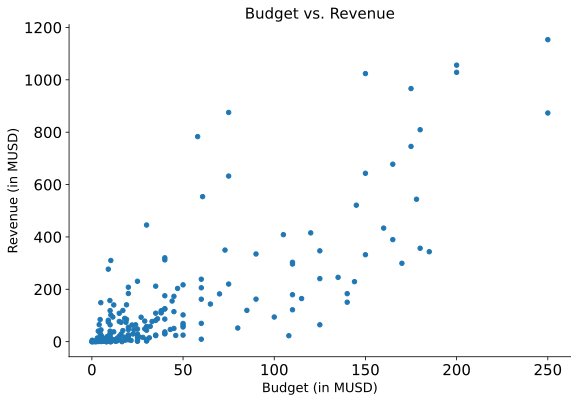

In [86]:
df.plot(kind = "scatter", x = "Budget", y = "Revenue", figsize = (9, 6), fontsize = 15)
plt.title("Budget vs. Revenue", fontsize = 15)
plt.xlabel("Budget (in MUSD)", fontsize = 13)
plt.ylabel("Revenue (in MUSD)", fontsize = 13)
ax = plt.gca()
ax.spines[["right" , "top"]].set_visible(False)
plt.show()

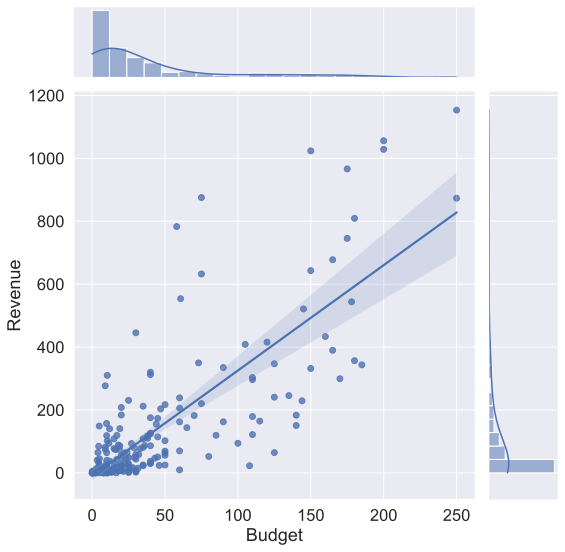

In [ ]:
sns.set(font_scale=1.5)
sns.jointplot(data = df , x = "Budget", y = "Revenue", height = 8  , kind = "reg")
plt.show()

### Creating a Confidence Interval for the Correlation Coefficient (Bootstrapping)

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
np.set_printoptions(precision=2, suppress= True)
%config InlineBackend.figure_format = 'svg'

In [ ]:
df = pd.read_csv("Budget_vs_Revenue.csv", parse_dates = ["Release_date"], index_col = "Release_date")

In [ ]:
df = df.loc["2016"]
df

In [ ]:
array = df.iloc[:, -2:].values
array

In [ ]:
array.shape

In [ ]:
np.corrcoef(array.T)[0, 1]

In [ ]:
size = array.shape[0]
size

__one bootstrap sample__

In [ ]:
np.random.seed(123)
indxs = np.random.randint(low = 0, high = size, size = size)

In [ ]:
indxs

In [ ]:
array[indxs]

In [ ]:
np.corrcoef(array[indxs].T)[0, 1]

__many bootstrap samples__

In [ ]:
sims = 100000

In [ ]:
np.random.seed(123)
indxs = np.random.randint(low = 0, high = size, size = size * sims).reshape(sims, size)

In [ ]:
indxs.shape

In [ ]:
indxs

In [ ]:
corr = []
for i in range(sims):
    corr.append(np.corrcoef(array[indxs[i]].T)[0, 1])

In [ ]:
corr

In [ ]:
plt.figure(figsize = (15, 10))
plt.hist(corr, bins = 500)
plt.show()

In [ ]:
np.min(corr)

__95% Confidence Interval Estimate__

In [ ]:
np.percentile(corr, [2.5, 97.5])

### Testing for Correlation (t-Test)

Calculate the __Correlation Coefficient__ (r) between __Movie Budgets__ and __Movie Revenues__ (for Movies released in 2016) and __test on a 5% significance level__, whether there is a linear relationship (H0: r == 0). 

In [ ]:
import pandas as pd
import scipy.stats as stats

In [ ]:
df = pd.read_csv("bud_vs_rev.csv", parse_dates = ["release_date"], index_col = "release_date")

In [ ]:
df = df.loc["2016"]

In [ ]:
df

__H0: r == 0__ <br>
__Ha: r != 0__

In [ ]:
r, p_value = stats.pearsonr(df.budget, df.revenue)

In [ ]:
r

In [ ]:
p_value

### A simple Linear Regression Model with numpy & scipy & seaborn

Create a __simple Linear Regression Model__ with the __independent variable Movie Budget__ and one __dependent variable Movie Revenue__. <br>
Visualize and interpret the __regression coefficients__.

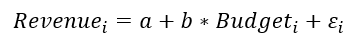

In [ ]:
import pandas as pd
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns
np.set_printoptions(precision=2, suppress= True)

In [ ]:
df = pd.read_csv("bud_vs_rev.csv", parse_dates = ["release_date"], index_col = "release_date")

In [ ]:
df = df.loc["2016"]

In [ ]:
df

In [ ]:
sns.set(font_scale=1.5)
sns.lmplot(data = df, x = "budget", y = "revenue", height = 8, ci = None)
plt.show()

__Linear Regression with numpy__

In [ ]:
x = df.iloc[:, -2].values
x

In [ ]:
y = df.iloc[:, -1].values
y

In [ ]:
reg = np.polyfit(x = x, y = y, deg = 1)
reg

In [ ]:
np.polyfit(x = df.budget, y = df.revenue, deg = 1)

In [ ]:
X = np.array([min(x), max(x)]) #creating x and y values for regression line

In [ ]:
X

In [ ]:
Y = np.polyval(reg, X)

In [ ]:
Y

In [ ]:
plt.figure(figsize = (12, 8))
plt.plot(X, Y)
plt.scatter(x = x, y = y)
plt.xlabel("Budget (in MUSD)")
plt.ylabel("Revenue (in MUSD)")
plt.show()

__Linear Regression with scipy__

In [ ]:
df

In [ ]:
stats.linregress(x = df.budget, y = df.revenue)

### How to interpret Regression Coefficients (Intercept and Slope)

In [ ]:
stats.linregress(x = df.budget, y = df.revenue)

In [ ]:
plt.figure(figsize = (12, 8))
plt.plot(X, Y)
plt.grid()
plt.scatter(x = x, y = y)
plt.xlabel("Budget (in MUSD)", fontsize = 15)
plt.ylabel("Revenue (in MUSD)", fontsize = 15)
plt.title("Linear Regression Model Revenue vs. Budget", fontsize = 15)
plt.show()

In [ ]:
df.budget.cov(df.revenue) / df.budget.var()

## Case Study (Part 1): The Market Model (Single Factor Model)

In [ ]:
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats

In [ ]:
df = yf.download(["MSFT", "^SP500TR"], start = "2015-12-31", end = "2018-12-31")

In [ ]:
df

In [ ]:
df = df["Adj Close"]

In [ ]:
df

In [ ]:
ret = df.pct_change().dropna()

In [ ]:
ret

In [ ]:
ret.plot(x = "^SP500TR", y = "MSFT", figsize = (12, 8), kind = "scatter")
plt.grid()
plt.title("MSFT vs. SP500 (daily returns)", fontsize = 15)
plt.show()

In [ ]:
r, p_value = stats.pearsonr(ret["^SP500TR"], ret.MSFT)

In [ ]:
r

In [ ]:
p_value

## Case Study (Part 2): The Market Model (Single Factor Model)

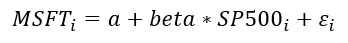

In [ ]:
beta, intercept, rvalue, pvalue, stderr = stats.linregress(x = ret["^SP500TR"], y = ret.MSFT)

In [ ]:
beta

In [ ]:
intercept

In [ ]:
rvalue

In [ ]:
sns.set(font_scale=1.5)
sns.lmplot(data = ret, x = "^SP500TR", y = "MSFT", height = 8, ci = None)
plt.show()